In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
GPU available: False


In [2]:
# Load cleaned data
oil = pd.read_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/oil_prices_cleaned.csv", 
                  index_col=0, parse_dates=True)

# Use only the Price column for LSTM
prices = oil[["Price"]].copy()

# Normalize the data between 0 and 1
# LSTM works much better with normalized data
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

print(f"Data shape: {prices_scaled.shape}")
print(f"Min value after scaling: {prices_scaled.min():.4f}")
print(f"Max value after scaling: {prices_scaled.max():.4f}")

Data shape: (4082, 1)
Min value after scaling: 0.0000
Max value after scaling: 1.0000


In [3]:
def create_sequences(data, sequence_length=60):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])  # last 60 days
        y.append(data[i, 0])                      # next day price
    return np.array(X), np.array(y)

# Create sequences
sequence_length = 60  # use last 60 days to predict next day
X, y = create_sequences(prices_scaled, sequence_length)

# Split into train and test (80/20)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for PyTorch - needs (samples, sequence, features)
X_train = torch.FloatTensor(X_train).unsqueeze(2)
X_test = torch.FloatTensor(X_test).unsqueeze(2)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print(f"Training samples: {X_train.shape}")
print(f"Testing samples: {X_test.shape}")

Training samples: torch.Size([3217, 60, 1])
Testing samples: torch.Size([805, 60, 1])


In [4]:
class OilLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(OilLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.2)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Take the last output
        out = self.fc(out[:, -1, :])
        return out

# Create model
model = OilLSTM()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

OilLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 50,497


In [5]:
# Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
batch_size = 32
train_losses = []

print("Training LSTM model...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    # Mini batch training
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        
        # Forward pass
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output.squeeze(), y_batch)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (len(X_train) // batch_size)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

print("\nTraining complete!")

Training LSTM model...
Epoch 10/50 - Loss: 0.003174
Epoch 20/50 - Loss: 0.001798
Epoch 30/50 - Loss: 0.001569
Epoch 40/50 - Loss: 0.001291
Epoch 50/50 - Loss: 0.001024

Training complete!


In [7]:
# Make predictions
model.eval()
with torch.no_grad():
    train_pred = model(X_train).squeeze().numpy()
    test_pred = model(X_test).squeeze().numpy()

# Inverse transform back to actual prices
train_pred = scaler.inverse_transform(train_pred.reshape(-1, 1))
test_pred = scaler.inverse_transform(test_pred.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Calculate accuracy metrics
mae = mean_absolute_error(y_test_actual, test_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
mape = np.mean(np.abs((y_test_actual - test_pred) / y_test_actual)) * 100

print(f"LSTM Results:")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"\nProphet Results for comparison:")
print(f"MAE:  $8.39")
print(f"RMSE: $9.32")
print(f"MAPE: 12.73%")

LSTM Results:
MAE:  $4.63
RMSE: $5.29
MAPE: 6.07%

Prophet Results for comparison:
MAE:  $8.39
RMSE: $9.32
MAPE: 12.73%


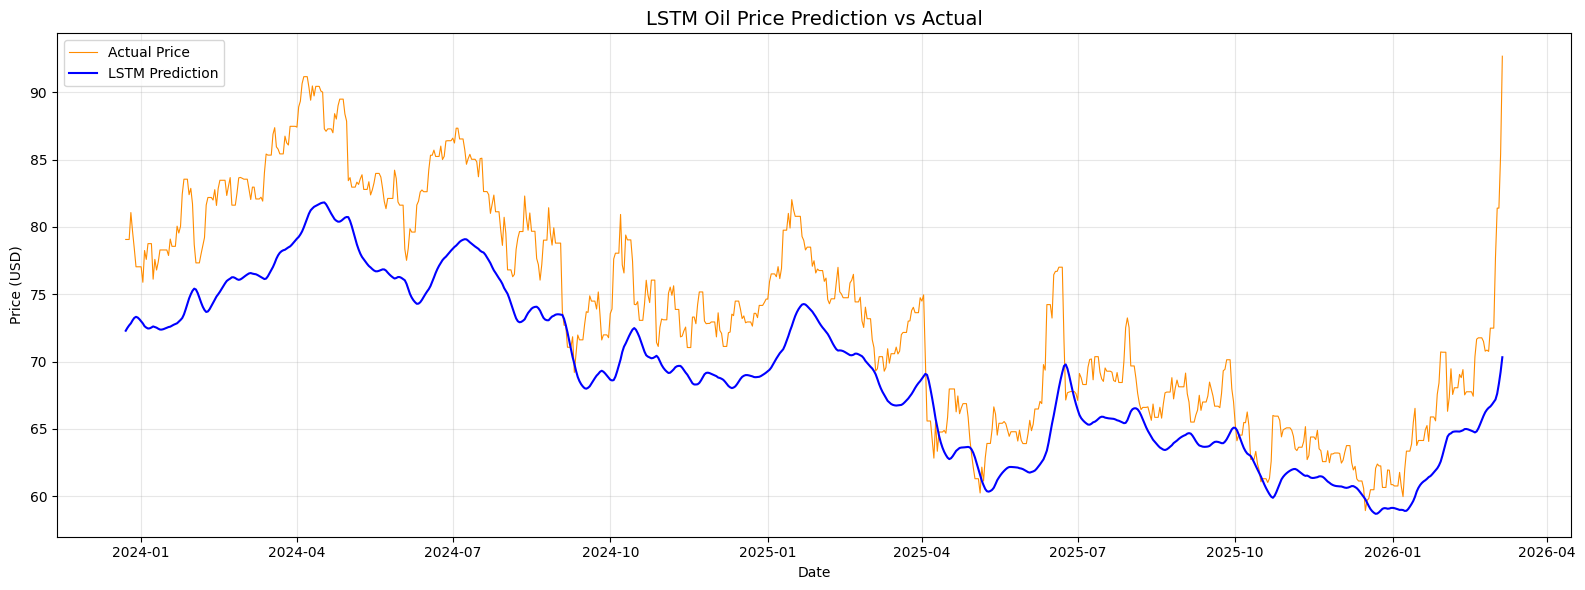

In [8]:
# Plot predictions vs actual
plt.figure(figsize=(16, 6))

# Get dates for test period
test_dates = oil.index[sequence_length + len(X_train):]

plt.plot(test_dates, y_test_actual, color="darkorange", linewidth=0.8, label="Actual Price")
plt.plot(test_dates, test_pred, color="blue", linewidth=1.5, label="LSTM Prediction")

plt.title("LSTM Oil Price Prediction vs Actual", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import pickle

# Save LSTM model
torch.save(model.state_dict(), 
    "C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/models/lstm_model.pth")

print("LSTM model saved!")

# Print final comparison
print("\n=== MODEL COMPARISON ===")
print(f"Prophet MAPE:  12.73% (87.27% accuracy)")
print(f"LSTM MAPE:      6.07% (93.93% accuracy)")
print(f"LSTM improvement: {12.73 - 6.07:.2f}% better than Prophet")


LSTM model saved!

=== MODEL COMPARISON ===
Prophet MAPE:  12.73% (87.27% accuracy)
LSTM MAPE:      6.07% (93.93% accuracy)
LSTM improvement: 6.66% better than Prophet
